<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 05

## Kernel methods

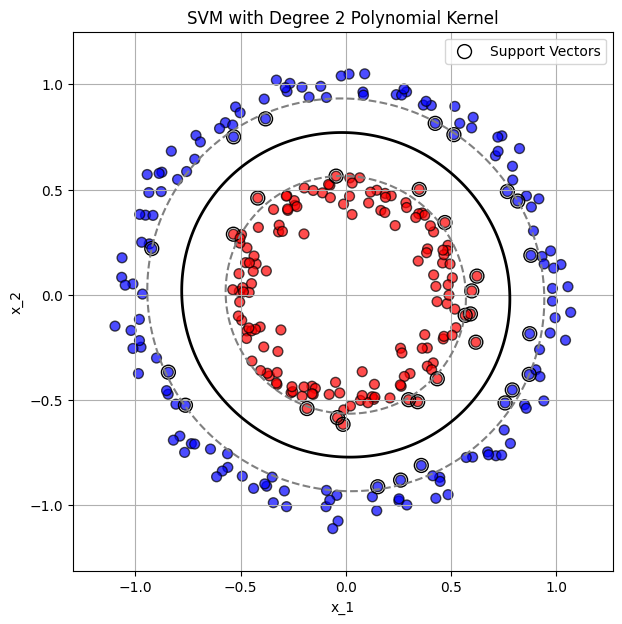

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# 1. Generate Data (Concentric Circles for Non-Linear Separation)
np.random.seed(42)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)

# Convert labels from (0,1) to (-1,1) for SVM
y = np.where(y == 0, -1, 1)

# 2. Train SVM with Polynomial Kernel (Degree 2, c=0)
clf = SVC(kernel='poly', degree=2, C=1.0, coef0=0, gamma=1)
# scikit uses a complex scaled gamma for the kernels. Here we want to use non-optimal (but simplest!) kernels
# K(x, x') = (x^T x')^2
clf.fit(X, y)

# 3. Create Meshgrid for Plotting Decision Boundary
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Flatten and Stack Grid for Prediction
grid = np.c_[xx.ravel(), yy.ravel()]
decision = clf.decision_function(grid)
decision = decision.reshape(xx.shape)

# 4. Plot Data Points and Decision Boundary
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7)

# Plot Decision Boundary and Margins
plt.contour(xx, yy, decision, levels=[0], linewidths=2, colors='k')
plt.contour(xx, yy, decision, levels=[-1, 1], linestyles='--', colors='grey')

# Highlight Support Vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=100, linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title('SVM with Degree 2 Polynomial Kernel')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.grid(True)

plt.gca().set_aspect('equal')  #  making the plot square
plt.show()


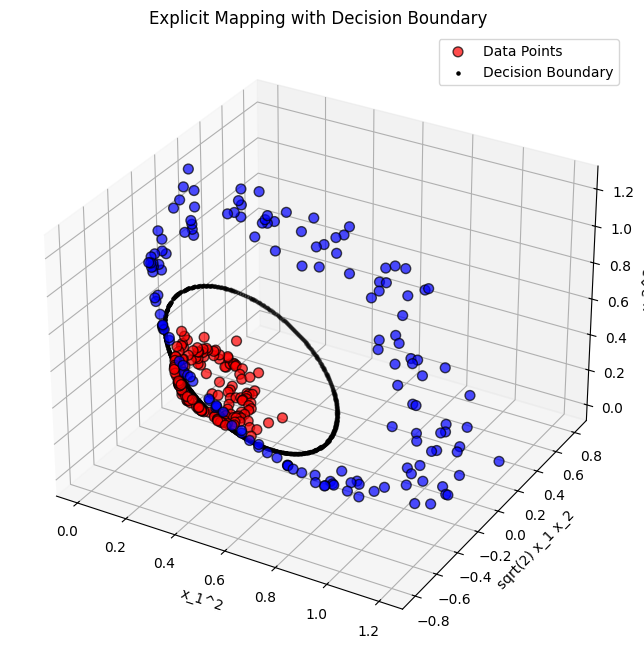

In [2]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

def phi(x):
    return [x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2]

# Apply phi(x) to each point
phi_X = np.array([phi(x) for x in X])

# Apply phi(x) to the meshgrid for decision boundary
phi_grid = np.array([phi(x) for x in grid])

# Scatter plot of transformed data
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

# Plot only the decision boundary contour (i.e. where decision == 0)
grid_decision = clf.decision_function(grid)
contour_mask = np.isclose(grid_decision, 0, atol=0.01)  # select points near decision boundary
ax.scatter(phi_grid[contour_mask, 0], phi_grid[contour_mask, 1], phi_grid[contour_mask, 2],
           c='k', s=5, label='Decision Boundary')

# Set axis labels and title for 3D plot
ax.set_title('Explicit Mapping with Decision Boundary')
ax.set_xlabel('x_1^2')
ax.set_ylabel('sqrt(2) x_1 x_2')
ax.set_zlabel('x_2^2')

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()


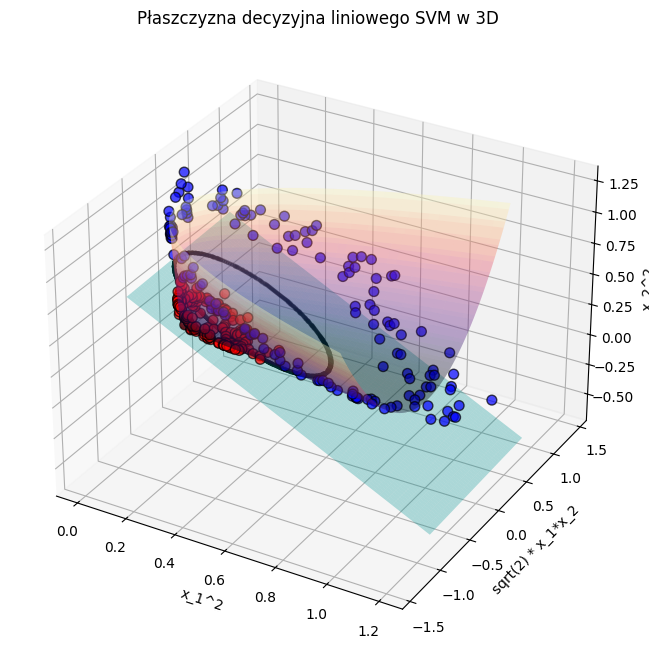

In [3]:
X = phi_X  # Używamy przekształconych danych phi(X) do rysowania płaszczyzny decyzyjnej

# Train a linear SVM classifier (clf)
clf = SVC(kernel='linear', C=1e5)
clf.fit(X, y)

# 3. Pobranie współczynników (wag) i wyrazu wolnego (bias)
w = clf.coef_[0]
b = clf.intercept_[0]

# 4. Tworzenie siatki (meshgrid) dla płaszczyzny na podstawie zakresu danych X i Y
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

# 5. Wyliczenie wartości Z dla każdego punktu na siatce X, Y
zz = (-w[0] * xx - w[1] * yy - b) / w[2]

# 6. Rysowanie wykresu 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Rysowanie punktów danych, pokolorowanych według klasy (y)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='bwr', s=50, edgecolors='k', alpha=0.7, label='Data Points')

# Plot only the decision boundary contour (i.e. where decision == 0)
contour_mask = np.isclose(grid_decision, 0, atol=0.01)  # select points near decision boundary
ax.scatter(phi_grid[contour_mask, 0], phi_grid[contour_mask, 1], phi_grid[contour_mask, 2],
           c='k', s=5, label='Decision Boundary')

# Rysowanie płaszczyzny oddzielającej
# Używamy alpha=0.3, aby płaszczyzna była półprzezroczysta i nie zasłaniała punktów
ax.plot_surface(xx, yy, zz, color='cyan', alpha=0.3, edgecolor='none')

# 1. Definiowanie dziedziny parametrów (x, y)
# Używamy siatki prostokątnej, która odwzoruje się w stożek.
# Zakres od -2 do 2 wystarczy, by zobaczyć strukturę.
r_max = 1
sample_points = 101 # Wyższa rozdzielczość dla gładkości

# Tworzymy 1D wektory parametrów x i y
x_params = np.linspace(-r_max, r_max, sample_points)
y_params = np.linspace(-r_max, r_max, sample_points)

# Tworzymy 2D siatkę parametrów (meshgrid)
X, Y = np.meshgrid(x_params, y_params)

# 2. Stosowanie parametryzacji f(x, y) = (x^2, sqrt(2)xy, y^2)
# U, V, W będą macierzami tej samej wielkości co X i Y
# ale będą reprezentować współrzędne w trójwymiarowej przestrzeni wyjściowej.
U = X**2
V = np.sqrt(2) * X * Y
W = Y**2

# 3. Rysowanie trójwymiarowego wykresu

# Używamy plot_surface do narysowania powierzchni.
# color='white' z edgecolor='black' (wireframe) pomaga zobaczyć strukturę,
# ale colormap (cmap) jest lepsza dla ciągłej powierzchni.
stożek = ax.plot_surface(U, V, W, cmap='magma', edgecolor='none', alpha=0.2)

# Ustawienie etykiet
ax.set_xlabel('x_1^2')
ax.set_ylabel('sqrt(2) * x_1*x_2')
ax.set_zlabel('x_2^2')
ax.set_title('Płaszczyzna decyzyjna liniowego SVM w 3D')

# Wyświetlenie wykresu
plt.show()

## Observations

An image of a $\mathbb{R}^2$ plane under the $\phi$ is a surface of a cone.
Indeed, we got
$$ x = a^2, y = \sqrt{2} ab, z = b^2. $$
So
$$ y^2 = 2xz. $$
If we do the rotation
$$ x = \frac{u + v}{\sqrt{2}}, z = \frac{u - v}{\sqrt{2}} $$
we got
$$ y^2 = u^2 - v^2. $$
So we get an equation of a cone
$$ y^2 + v^2 = u^2. $$

## Primary Question

1. Answer what would be a preimage of the hyperplane in original 2D.

It we will be an intersection of a plane and a cone, so it will be circle that is a boundary in 2D.

2. Why does the SVM's decision boundary we plotted in class in both the higher-dimensional (3D) feature space and the original lower-dimensional (2D) space not look like a “flat” hyperplane, even though we know the classifier’s separating surface is mathematically linear in 3D feature space?

It is linear in a tangent space on the given manifold in 3D, a cone in our case.
It is not linear in 2D, so also no under the $\phi$.

## Secondary Question

1. Explain why and how a hyperplane in 3D becomes a circular (or elliptical) curve when viewed back in the original 2D plane of the dataset.

If we think that we are on manifold in 3D then we gave the answer already.

